# Dimensiereductie

Auteurs: Brian van der Bijl (brian.vanderbijl@hu.nl), Tijmen Muller

- Studentnummer: 1892983
- Naam: Richard Peach
- Datum: 6 maart 2026

## Deel I: Principal Component Analysis (PCA)

Het _Principal Component Analysis_ (PCA) algoritme kan gebruikt worden om het aantal dimensies van een dataset te reduceren tot de belangrijkste componenten. Als de originele dataset $n$ dimensies heeft, dan kunnen we met onderstaande stappen dit terugbrengen tot een (zelfgekozen) aantal van $n^\prime$ dimensies.

1. Centreer de data.
2. Bereken de covariantie van alle features onderling. 
3. Bereken de Eigenvectors en Eigenvalues van de covariantiematrix.
4. Kies de $n^\prime$ Eigenvectors om de dimensiereductie mee uit te voeren.
5. Vermenigvuldig de $n^\prime$ Eigenvectors met de originele data om de reductie toe te passen.

### Context

Gegeven is een databestand met embeddings van 200 tekstfragmenten. Elke embedding bestaat in 15 dimensies, en is gelabeled met een categorie. We gaan dimensionaliteitsreductie toepassen om de data te kunnen plotten.

De categorie geeft aan in welk genre de tekstfragmenten thuishoren. Daarnaast is onderscheid gemaakt tussen het perspectief waarin het fragment geschreven is: ik (1st person) of hij/haar/hen (3rd person):
- Fantasy (1st person)
- Fantasy (3rd person)
- Science Fiction (1st person)
- Science Fiction (3rd person)
- Romance (1st person)
- Romance (3rd person)
- Crime (1st person)
- Crime (3rd person)

In [52]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Show floats on 3 digits, suppress scientific notation
np.set_printoptions(precision=3, suppress=True)

In [53]:
with open('data.pkl', 'rb') as file:
    data = pickle.load(file)

data.sample(5)

e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,e_9,e_10,e_11,e_12,e_13,e_14,e_15,label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1.310425,0.937092,1.055541,1.109011,0.70207,3.793066,0.122211,2.812553,1.164479,0.776713,0.800708,1.327549,0.365186,0.795637,0.327084,"""Fantasy (1st person)"""
0.852917,0.498745,0.562205,1.241597,1.222805,4.905315,0.969537,1.408766,0.762109,0.699757,1.081044,1.138446,0.956955,1.639957,0.59594,"""Romance (3rd person)"""
1.555254,1.059302,0.75325,0.946138,0.554892,4.534702,0.402356,2.386463,1.134903,1.076016,0.821317,0.472914,0.895345,0.95907,0.847824,"""Crime (1st person)"""
1.038091,0.371515,0.700536,1.563465,0.846023,4.070364,0.771771,2.500086,0.961897,1.342522,1.363518,0.681066,0.504599,0.419872,0.843703,"""Crime (1st person)"""
1.75366,1.031907,0.898449,1.118782,0.656212,5.867586,1.140568,0.593038,0.074024,1.397105,0.30324,0.343267,0.957534,0.534475,0.878946,"""Romance (1st person)"""


### Voorbereidende opdracht

Gegeven een dataset met $m$ datapunten met elk $n$ features en een gewenste reductie tot $n^\prime$ dimensies. Bepaal voor elk van de vijf stappen van het algoritme wat de dimensies (oftewel `shape`) is van de volgende tussenresultaten:

0. De matrix met de originele dataset.
1. De matrix met de gemiddelden per feature om de data mee te centreren.
2. De covariantiematrix.
3. De matrix met de Eigenvectors en de matrix met de Eigenvalues.
4. De matrix met de _geselecteerde_ Eigenvectors.
5. De matrix met de _gereduceerde_ data.

_Mijn antwoord:_

0. De shape is (m, n)
1. De shape is (1, n)
2. De shape is (n, n)
3. De shape van de eigenvectors is (n, n) en die van de eigenvalues is (n,)
4. De shape is (n, n')
5. De shape is (m, n')

### Opdracht 1. Implementatie

Schrijf een eigen implementatie van het PCA-algoritme `compute_pca(X, n_components)` volgens eerdergenoemde stappen van het algoritme. Maak slim gebruik van fucties van `numpy` waar mogelijk, maar zorg wel dat je begrijpt wat je in elke stap doet. De laatste stap is al gegeven in de functiedefinitie hieronder.

Hint: Laat bij stap 3. zien (bijvoorbeeld met een `print()` statement) dat de meest informatieve Eigenvalue al meer dan 50% van de informatie bevat van onze dataset.

#### Input
- `X: numpy.array` - numpy matrix met dimensies $(m, n)$; elke rij is een datapunt in $n$ dimensies
- `n_components: int` - het gewenste aantal dimensies $n^\prime$

#### Output
`X_reduced: numpy.array` - een $(m, n^\prime)$ numpy matrix met de gereduceerde data.

In [54]:
def compute_pca(X, n_components):
    """
    Parameters
    ----------
    X : numpy.ndarray
        Input data matrix of shape (m, n), where m is the number of samples and n is the number of features.
    n_components : int
        The number of principal components (dimensions) to keep.

    Returns
    -------
    X_reduced : numpy.ndarray
        The data projected onto the top n_components principal components.
    """
    arr = np.array(X)
    
    # Stap 1: Centreer de data.
    gem = np.mean(arr, axis=0)
    arr_gecentreerd = arr - gem
    
    # Stap 2: Bereken de covariantie van alle features onderling.
    cov_matrix = (arr_gecentreerd.T @ arr_gecentreerd) / (arr.shape[0] - 1)
    
    # Stap 3: Bereken de Eigenvectors en Eigenvalues van de covariantiematrix. (eigh sorteerd al van klein naar groot)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # In deze prints zie je de eigenwaardes en hoeveel procent van de informatie de meest informatieve Eigenvalue bevat
    print("Eigenwaarden:", eigenvalues)
    print("Percentage van de informatie dat de meest informatieve Eigenvalue bevat:", eigenvalues[-1] / np.sum(eigenvalues) * 100)

    # Percentage van informatie dat bewaart blijft
    print(f"Percentage van informatie dat bewaart is: {np.sum(eigenvalues[-n_components:]) / np.sum(eigenvalues) * 100:.1f}%")

    # Stap 4: Kies de n' Eigenvectors om de dimensiereductie mee uit te voeren.
    # Ik draai met [:, ::-1] de volgorde van de kolommen om zodat de output gelijk is met de test output
    n_eigenvectors = eigenvectors[:, -n_components:][:, ::-1]
    
    # Stap 5: Vermenigvuldig de n' Eigenvectors met de originele data om de reductie toe te passen.
    return arr_gecentreerd @ n_eigenvectors

    

#### Test-scenario
Onderstaande code zou de volgende output moeten opleveren (het minteken kan wisselen):

```python
[[ 0.43437323 -0.49820384]
 [ 0.42077249  0.50351448]
 [-0.85514571 -0.00531064]]
 ```

In [55]:
np.random.seed(1)
X = np.random.rand(3, 10)
X_reduced = compute_pca(X, n_components=2)
print(X_reduced)

Eigenwaarden: [-0.    -0.    -0.     0.     0.     0.     0.     0.     0.251  0.549]
Percentage van de informatie dat de meest informatieve Eigenvalue bevat: 68.61566122734342
Percentage van informatie dat bewaart is: 100.0%
[[ 0.434  0.498]
 [ 0.421 -0.504]
 [-0.855  0.005]]


### Opdracht 2. Visualisatie met dimensiereductie

Maak op basis van de aangeleverde `data` een numpy array van de datapunten, en gebruik je PCA-implementatie om een 2D- en 3D-weergave van de data te maken. Maak van elke weergave een plot, waarbij iedere categorie een eigen kleur krijgt.

Eigenwaarden: [0.036 0.036 0.042 0.045 0.052 0.054 0.06  0.069 0.084 0.114 0.158 0.194
 0.354 0.733 2.113]
Percentage van de informatie dat de meest informatieve Eigenvalue bevat: 50.981346028749485
Percentage van informatie dat bewaart is: 68.7%


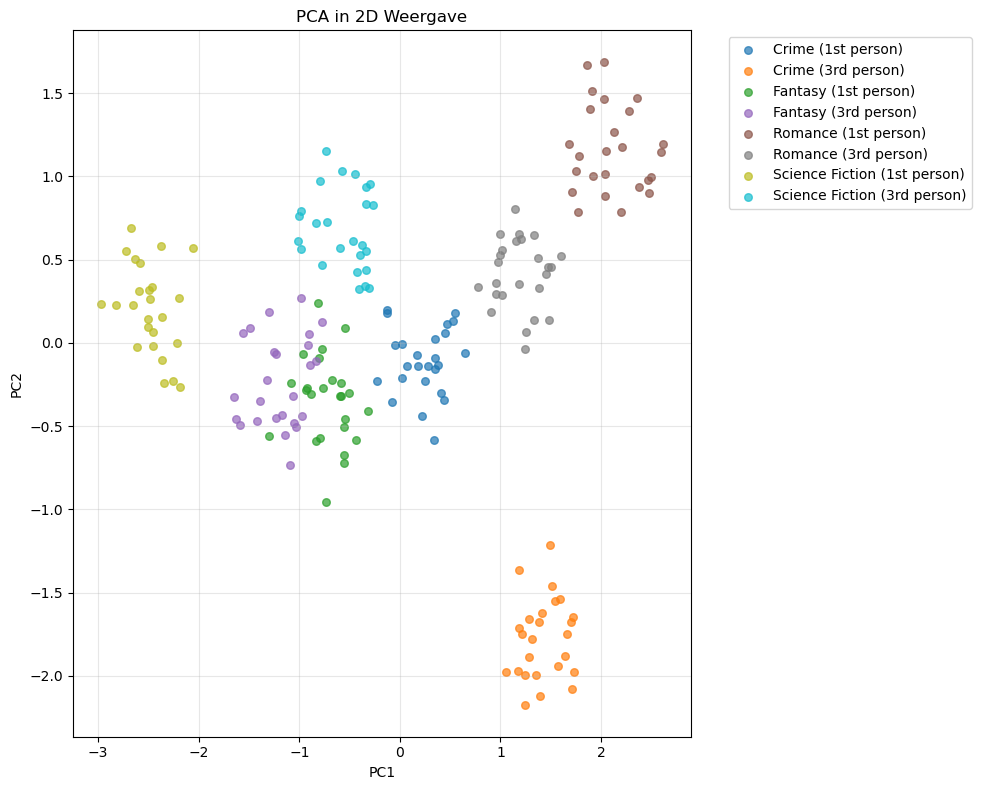

In [56]:
feature_columns = [f'e_{i}' for i in range(1, 16)]
X = data[feature_columns]
y = data['label']

X_2d_pca= compute_pca(X, n_components=2)

plt.figure(figsize=(10, 8))
unique_labels = np.unique(y)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = y == label
    plt.scatter(X_2d_pca[mask, 0], X_2d_pca[mask, 1], 
               c=[color], label=label, alpha=0.7, s=30)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA in 2D Weergave')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Eigenwaarden: [0.036 0.036 0.042 0.045 0.052 0.054 0.06  0.069 0.084 0.114 0.158 0.194
 0.354 0.733 2.113]
Percentage van de informatie dat de meest informatieve Eigenvalue bevat: 50.981346028749485
Percentage van informatie dat bewaart is: 77.2%


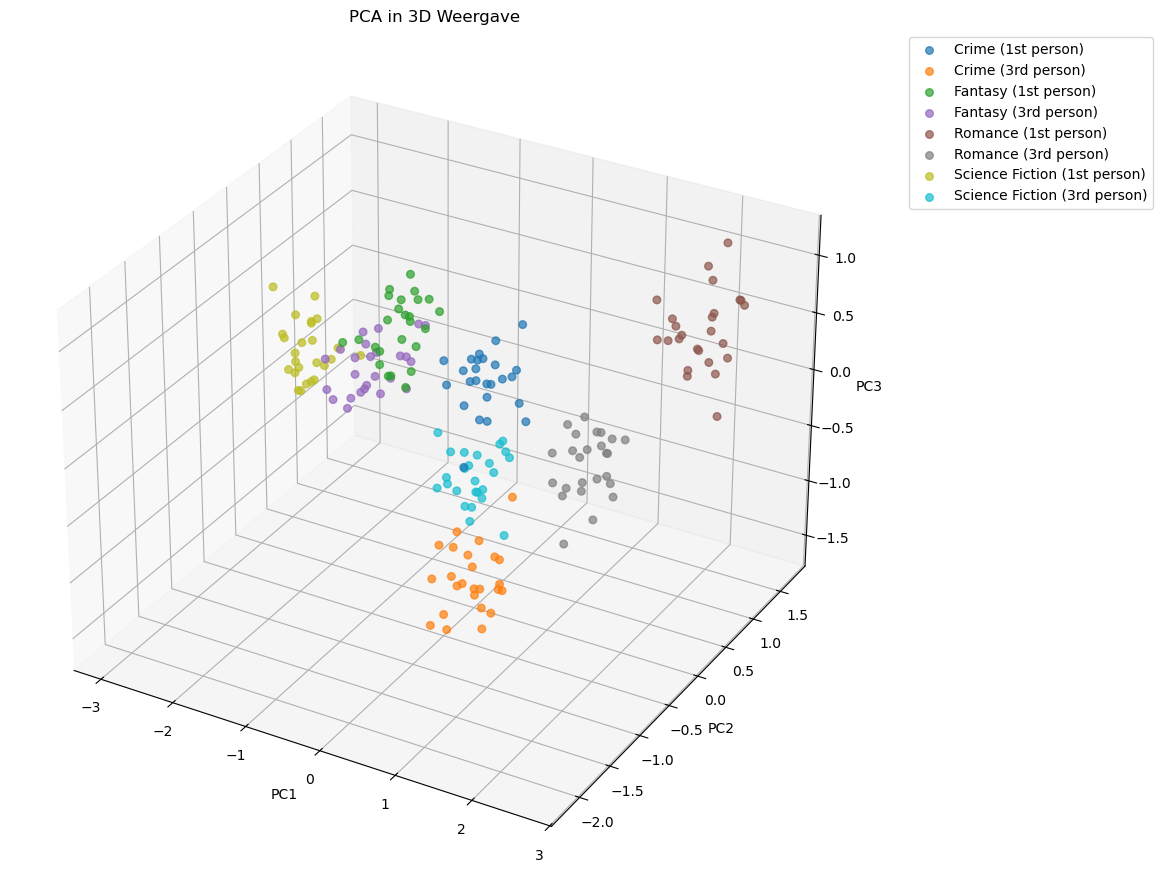

In [57]:
X_3d_pca = compute_pca(X, n_components=3)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for label, color in zip(unique_labels, colors):
    mask = y == label
    ax.scatter(X_3d_pca[mask, 0], X_3d_pca[mask, 1], X_3d_pca[mask, 2],
              c=[color], label=label, alpha=0.7, s=30)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA in 3D Weergave')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Uitzoeken hoeveel dimensies nodig zijn om 90 of 95 procent van de informatie te bewaren

In [58]:
compute_pca(X, n_components=6)
compute_pca(X, n_components=7)

compute_pca(X, n_components=10)
compute_pca(X, n_components=11)

print("\n Dus 7 dimensies zijn minimaal nodig om 90 procent te bewaren, en 11 dimensies zijn minimaal nodig om 95 procent te bewaren")

Eigenwaarden: [0.036 0.036 0.042 0.045 0.052 0.054 0.06  0.069 0.084 0.114 0.158 0.194
 0.354 0.733 2.113]
Percentage van de informatie dat de meest informatieve Eigenvalue bevat: 50.981346028749485
Percentage van informatie dat bewaart is: 88.5%
Eigenwaarden: [0.036 0.036 0.042 0.045 0.052 0.054 0.06  0.069 0.084 0.114 0.158 0.194
 0.354 0.733 2.113]
Percentage van de informatie dat de meest informatieve Eigenvalue bevat: 50.981346028749485
Percentage van informatie dat bewaart is: 90.5%
Eigenwaarden: [0.036 0.036 0.042 0.045 0.052 0.054 0.06  0.069 0.084 0.114 0.158 0.194
 0.354 0.733 2.113]
Percentage van de informatie dat de meest informatieve Eigenvalue bevat: 50.981346028749485
Percentage van informatie dat bewaart is: 94.9%
Eigenwaarden: [0.036 0.036 0.042 0.045 0.052 0.054 0.06  0.069 0.084 0.114 0.158 0.194
 0.354 0.733 2.113]
Percentage van de informatie dat de meest informatieve Eigenvalue bevat: 50.981346028749485
Percentage van informatie dat bewaart is: 96.2%

 Dus 7 dime

### Opdracht 3. Analyse

Analyseer de resultaten:
1. Welke categorieën zijn op basis van de PCA-reductie te onderscheiden, en welke niet? 
2. Geef aan hoeveel procent van de informatie bewaard is gebleven in 2D en 3D respectievelijk.
3. Hoeveel dimensies zijn nodig om 90% van de informatie te bewaren?
4. En voor 95%?

_Mijn antwoord:_

1. Fantasy 3rd person (paars) is niet gescheiden van Fantasy 1st person (groen). Voor de rest is elke categorie gescheiden.
2. Bij 2D is 68,7% bewaard gebleven, bij 3D is 77,2% bewaard gebleven.
3. Er zijn minimaal 7 dimensies nodig om 90% van de informatie te bewaren. (Zie onderzoekje net voor opdracht 3)
4. Er zijn minimaal 11 dimensies nodig om 95% van de informatie te bewaren.

## Deel II: t-Distributed Stochastic Neighbour Embedding (t-SNE)

Een alternatieve methode voor dimensiereductie is _t-Distributed Stochastic Neighbour Embedding_ (t-SNE). 

### Opdracht 4. Toepassing
Gebruik SciKit-Learn om met behulp van t-SNE de data tot 2 dimensies te reduceren en plot het resultaat (wederom met kleuren voor de categorien). 

In [59]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

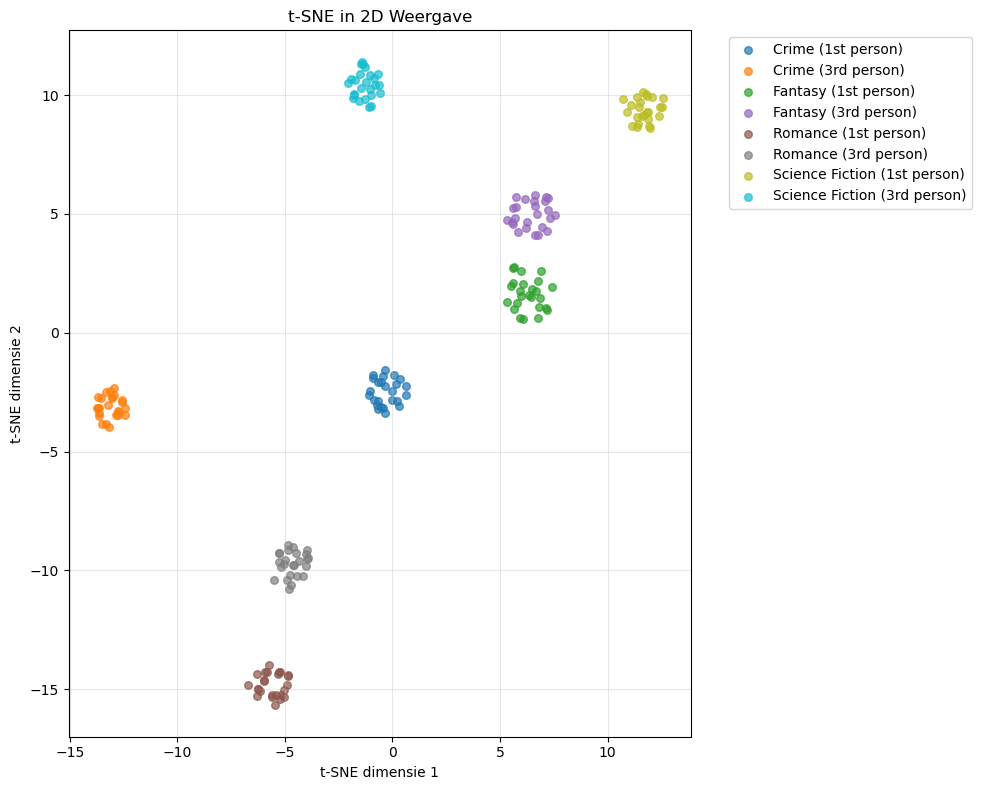

In [60]:
plt.figure(figsize=(10, 8))
unique_labels = np.unique(y)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = y == label
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
               c=[color], label=label, alpha=0.7, s=30)

plt.xlabel('t-SNE dimensie 1')
plt.ylabel('t-SNE dimensie 2')
plt.title('t-SNE in 2D Weergave')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Opdracht 5. Vergelijking

Vergelijk deze met de resultaten van je PCA-implementatie:

1. Hoe verhoudt de zichtbaarheid van de categorieën zich tussen beide resultaten?
2. Hoe verhouden de algoritmes zich in het behoud van informatie?

Beantwoord de volgende vragen los van de data van deze opdracht:

3. Waarvoor zou je PCA en t-SNE inzetten als je te maken krijgt met een onbekende (mogelijk ongelabelde) dataset?
4. Geef een voorbeeld waar PCA de voorkeur heeft boven t-SNE.
5. Geef een voorbeeld waar t-SNE de voorkeur heeft boven PCA.

_Mijn antwoord:_

1. Bij t-SNE zijn de categoriëen veel duidelijker gescheiden dan bij PCA
2. Bij PCA kan je bijhouden hoeveel informatie wordt bewaard. PCA kijkt vooral naar globale variantie en bewaart de informatie die daarvoor nodig is.
   Bij t-SNE kan je niet goed weten hoeveel informatie wordt bewaard. t-SNE bewaard de lokale structuur en bewaart dus vooral lokale informatie.

3. Ik zou PCA en t-SNE (of dimensionaliteitsreductie in het algemeen) om de data makkelijker te kunnen visualiseren en om te zien of er clusters in zitten. Dit kan ook als er geen labels zijn.
4. PCA is meestal veel sneller, dus als de dataset heel groot is is PCA waarschijnlijk de betere optie. 
5. Als je veel uitschieters hebt kan t-SNE de voorkeur hebben omdat t-SNE minder gevoelig is voor uitschieters.

### Opdracht 6. Project

Als het goed is, heb je op dit moment een eerste idee van de data waar je in het project mee gaat werken. Geef antwoord op onderstaande vragen.

1. Wat is de dimensionaliteit waar je mee te maken hebt?
2. Beschrijf hoe dimensionaliteitsreductie-algoritmen je kunnen helpen de data te verkennen.

_Mijn antwoord:_

1. De gekregen data bestaat uit 4k foto's in RGB. 
   Dat is 3840 × 2160 = 8.294.400 pixels per foto.
   Per pixel zijn er 3 kleurwaardes dus 8.294.400 * 3 = 24.883.200 dimensies

   De dimensionaliteit is dus per foto 24.883.200 dimensies.

   We kunnen wel de foto's in stukken gaan snijden of croppen om minder dimensies per foto te hebben.

2. Dimensionaliteitsreductie-algoritmen kunnen zeker gaan helpen om onze data te gaan verkennen en begrijpen. Als we onze data bestaande uit foto's met super hoge dimensionaliteit om zetten naar 2 of 3 dimensies kunnen we veel makkelijker patronen gaan herkennen in de data.